# CelebA Wild 21k — Three-Stage Face Front-End v0.1

**Pipeline**

```text
full CelebA in the Wild
    -> immutable identity split
    -> OpenCV YuNet bbox
    -> Double 2-stack Hourglass (Stack 2)
    -> inverse-mapped 5 landmarks
    -> 5-point Umeyama similarity aligner
    -> aligned 112 x 112 RGB
    -> exact 21k identity-disjoint export
```

This notebook is the first integrated implementation of the accepted three-stage front end.

## Frozen contracts

- **YuNet**: Stage 0 bbox detector; CelebA policy = largest detected face.
- **Double Hourglass**: 256×256 RGB input, aspect-preserving resize, centered black padding, `(x - 0.5) / 0.5`, Stack 2, argmax heatmap decoder.
- **Landmark order**: `lefteye, righteye, nose, leftmouth, rightmouth`.
- **Aligner**: 5-point least-squares similarity transform (Umeyama), output 112×112 RGB.
- **Dataset source**: full CelebA Wild; the old 40k Hourglass-training subset is explicitly not used as a source dataset.
- **Split**: identity-disjoint and defined before model-dependent preprocessing.
- **GT bbox / GT landmarks**: diagnostic-only; never used as production inputs or selection criteria.

## Final target

```text
train                 16,000
validation             2,000
test/query              1,000
test/distractors        2,000
TOTAL                  21,000
```

The authoritative artifact is `master_manifest.csv`; output directories are an export representation only.

## 0. Runtime notes

Designed primarily for the local MacBook Air M4 workflow.

- YuNet runs through OpenCV on CPU.
- Double Hourglass uses `mps` when available, otherwise CUDA, otherwise CPU.
- The notebook is restartable: successful candidate processing is recorded and can be reused.
- Candidate/reserve counts are intentionally larger than final quotas. If technical failures exhaust a reserve, finalization stops rather than violating the split contract.

In [ ]:
# Optional one-time dependency installation.
# Uncomment only if your current environment is missing a package.
#
# %pip install -U numpy pandas pillow matplotlib tqdm opencv-python torch

## 1. CONFIG — edit this cell only

In [1]:
from pathlib import Path
from dataclasses import dataclass

@dataclass
class Config:
    # ------------------------------------------------------------------
    # FULL CelebA Wild source — NOT the old 20k/40k Hourglass subset.
    # ------------------------------------------------------------------
    celeba_root: Path = Path(
        "/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/"
        "24-10_FinalProject/CelebA__original_wild_images"
    )
    identity_file: Path = Path(
        "/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/"
        "24-10_FinalProject/CelebA_new260715/Anno/identity_CelebA.txt"
    )

    # Diagnostic-only native CelebA annotations.
    # Set to None if diagnostics are not required for the first run.
    gt_bbox_file: Path | None = Path(
        "/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/"
        "24-10_FinalProject/CelebA_new260715/Anno/list_bbox_celeba.txt"
    )
    gt_landmarks_file: Path | None = Path(
        "/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/"
        "24-10_FinalProject/CelebA_new260715/Anno/list_landmarks_celeba.txt"
    )

    # Runtime models.
    yunet_model: Path = Path(
        "/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/"
        "24-10_FinalProject/Pipeline_stage/0_align_block_for/doc/face_detection_yunet_2023mar.onnx"
    )
    double_hourglass_checkpoint: Path = Path(
        "/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/"
        "24-10_FinalProject/Pipeline_stage/0_align_block_for/doc/double_hourglass_best.pt"
    )
    # Output root for this 21k pipeline.
    output_root: Path = Path(
        "/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/"
        "24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1"
    )

    # ------------------------------------------------------------------
    # Reproducibility / split contract
    # ------------------------------------------------------------------
    seed: int = 42

    train_target: int = 16_000
    val_target: int = 2_000
    query_target: int = 1_000
    distractor_target: int = 2_000

    # Final identity-role preferences.
    query_images_per_id: int = 4
    val_images_per_id: int = 4
    train_min_images_per_id: int = 4
    train_preferred_images_per_id: int = 8

    # Immutable identity-pool construction.
    # Query candidates and distractor candidates are distinct test identities.
    test_query_candidate_ids: int = 350     # target 250 + reserve
    test_distractor_candidate_ids: int = 2_150  # target 2000 + reserve
    val_pool_ids: int = 600

    # Processing candidate budget.
    train_candidate_ids: int = 3_500
    val_candidate_ids: int = 550

    train_candidate_images_per_id: int = 10
    val_candidate_images_per_id: int = 5
    query_candidate_images_per_id: int = 5
    distractor_candidate_images_per_id: int = 2

    # ------------------------------------------------------------------
    # YuNet — frozen Stage 0
    # ------------------------------------------------------------------
    yunet_score_threshold: float = 0.6
    yunet_nms_threshold: float = 0.3
    yunet_top_k: int = 5000
    yunet_max_inference_side: int = 640

    # ------------------------------------------------------------------
    # Double Hourglass — frozen Stage 1
    # ------------------------------------------------------------------
    hg_image_size: int = 256
    hg_heatmap_size: int = 64
    hg_num_landmarks: int = 5
    hg_feature_channels: int = 256
    hg_depth: int = 4
    hg_blocks_per_level: int = 1

    # Technical landmark QC only. This is not ArcFace-based curation.
    require_predicted_landmarks_inside_crop: bool = True
    landmark_crop_tolerance_px: float = 2.0
    min_predicted_eye_distance_px: float = 2.0

    # ------------------------------------------------------------------
    # Aligner — frozen Stage 2
    # ------------------------------------------------------------------
    aligned_size: int = 112

    # Execution.
    checkpoint_every: int = 100
    reprocess_existing: bool = False
    save_staging_aligned: bool = True

    # Diagnostics.
    diagnostic_sample_n: int = 20

CFG = Config()

CFG.output_root.mkdir(parents=True, exist_ok=True)
(CFG.output_root / "staging_aligned").mkdir(parents=True, exist_ok=True)
(CFG.output_root / "celeba_21k_aligned/train").mkdir(parents=True, exist_ok=True)
(CFG.output_root / "celeba_21k_aligned/validation").mkdir(parents=True, exist_ok=True)
(CFG.output_root / "celeba_21k_aligned/test/query").mkdir(parents=True, exist_ok=True)
(CFG.output_root / "celeba_21k_aligned/test/distractors").mkdir(parents=True, exist_ok=True)

print(CFG)

Config(celeba_root=PosixPath('/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/CelebA__original_wild_images'), identity_file=PosixPath('/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/CelebA_new260715/Anno/identity_CelebA.txt'), gt_bbox_file=PosixPath('/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/CelebA_new260715/Anno/list_bbox_celeba.txt'), gt_landmarks_file=PosixPath('/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/CelebA_new260715/Anno/list_landmarks_celeba.txt'), yunet_model=PosixPath('/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/doc/face_detection_yunet_2023mar.onnx'), double_hourglass_checkpoint=PosixPath('/Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/doc/double_hourglass_best.pt'), output_

## 2. Imports, device and hard guards

The source root is explicitly rejected if it looks like the historical 20k/40k reduced Hourglass dataset.  
The Double Hourglass **weights may of course have been trained on the old 40k set**; only the dataset source is forbidden from pointing there.

In [2]:
import gc
import hashlib
import math
import os
import shutil
import time
import urllib.request
from collections import Counter
from itertools import combinations

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

def choose_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = choose_device()

for required_name, required_path in {
    "celeba_root": CFG.celeba_root,
    "identity_file": CFG.identity_file,
}.items():
    if not required_path.exists():
        raise FileNotFoundError(f"{required_name} not found: {required_path}")

source_text = str(CFG.celeba_root).lower()
if "40k" in source_text or "20k" in source_text or "hourglass_40" in source_text:
    raise RuntimeError(
        "CELEBA SOURCE points to a historical reduced Hourglass dataset. "
        "This notebook must start from the full CelebA Wild source."
    )

print("DEVICE:", DEVICE)
print("PyTorch:", torch.__version__)
print("OpenCV:", cv2.__version__)
print("CelebA root:", CFG.celeba_root)
print("Output root:", CFG.output_root)

DEVICE: mps
PyTorch: 2.9.1
OpenCV: 4.13.0
CelebA root: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/CelebA__original_wild_images
Output root: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1


## 3. Recursive source index + native identity table

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def is_inside(path: Path, directory: Path) -> bool:
    try:
        path.resolve().relative_to(directory.resolve())
        return True
    except ValueError:
        return False

def build_recursive_image_index(root: Path, excluded_root: Path):
    index = {}
    duplicates = {}

    for p in tqdm(root.rglob("*"), desc="Indexing CelebA Wild"):
        if not p.is_file() or p.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        if is_inside(p, excluded_root):
            continue

        name = p.name
        if name in index:
            duplicates.setdefault(name, [index[name]]).append(p)
        else:
            index[name] = p

    if duplicates:
        examples = {
            k: [str(x) for x in v]
            for k, v in list(duplicates.items())[:5]
        }
        raise ValueError(
            "Duplicate source filenames detected. "
            f"Examples: {examples}"
        )
    return index

def read_identity_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(
        path,
        sep=r"\s+",
        names=["filename", "identity_id"],
        engine="python",
    )
    df["filename"] = df["filename"].astype(str)
    df["identity_id"] = pd.to_numeric(df["identity_id"], errors="raise").astype(int)

    if df["filename"].duplicated().any():
        dup = df.loc[df["filename"].duplicated(), "filename"].head().tolist()
        raise ValueError(f"Duplicate identity rows: {dup}")
    return df

image_index = build_recursive_image_index(CFG.celeba_root, CFG.output_root)
identity_df = read_identity_file(CFG.identity_file)

identity_df["source_exists"] = identity_df["filename"].isin(image_index)
identity_df["raw_path"] = identity_df["filename"].map(
    lambda x: str(image_index[x]) if x in image_index else ""
)

print("Identity rows:", f"{len(identity_df):,}")
print("Indexed source images:", f"{len(image_index):,}")
print("Matched source images:", f"{identity_df['source_exists'].sum():,}")
print("Unique identities:", f"{identity_df['identity_id'].nunique():,}")

display(identity_df.head())

Indexing CelebA Wild: 0it [00:00, ?it/s]

Identity rows: 202,599
Indexed source images: 202,598
Matched source images: 202,598
Unique identities: 10,177


,filename,identity_id,source_exists,raw_path
0,000001.jpg,2880,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...
1,000002.jpg,2937,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...
2,000003.jpg,8692,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...
3,000004.jpg,5805,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...
4,000005.jpg,9295,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...


## 4. Build immutable identity pools and candidate queues

This is the leakage-critical cell.

Pool assignment uses **only**:

- native identity labels;
- source-file existence;
- raw image counts;
- a deterministic seed-derived ranking.

No bbox result, landmark result, alignment result, ArcFace embedding, NME, TPR@FPR or recognition result participates in pool assignment.

The final query/distractor roles are also pre-separated at the identity level. Technical failures may consume reserve identities **within the same role**, but identities never migrate between train, validation, query or distractor roles.

In [4]:
MASTER_PATH = CFG.output_root / "master_manifest.csv"

def stable_rank(value, seed=42):
    token = f"{seed}|{value}".encode("utf-8")
    return int.from_bytes(hashlib.sha256(token).digest()[:8], "big")

def build_master_manifest(identity_df: pd.DataFrame) -> pd.DataFrame:
    df = identity_df.copy()
    df = df[df["source_exists"]].copy()

    raw_counts = df.groupby("identity_id").size().rename("raw_image_count")
    stats = raw_counts.reset_index()
    stats["rank"] = stats["identity_id"].map(lambda x: stable_rank(int(x), CFG.seed))

    eligible4 = stats[stats["raw_image_count"] >= 4].sort_values("rank").copy()

    needed_rich = CFG.test_query_candidate_ids + CFG.val_pool_ids + CFG.train_candidate_ids
    if len(eligible4) < needed_rich:
        raise RuntimeError(
            f"Not enough identities with >=4 raw images: {len(eligible4):,}; "
            f"configured rich-identity demand is {needed_rich:,}. "
            "Reduce candidate reserves only after inspecting identity statistics."
        )

    # Pre-reserve query-capable test identities.
    test_query_ids = set(
        eligible4.iloc[:CFG.test_query_candidate_ids]["identity_id"].astype(int)
    )

    remaining_after_query = stats[~stats["identity_id"].isin(test_query_ids)].copy()

    # Validation pool uses >=4 raw images.
    val_eligible = eligible4[~eligible4["identity_id"].isin(test_query_ids)].sort_values("rank")
    val_ids = set(val_eligible.iloc[:CFG.val_pool_ids]["identity_id"].astype(int))

    # Distractor identities are distinct from query and validation identities.
    distractor_pool = remaining_after_query[
        ~remaining_after_query["identity_id"].isin(val_ids)
    ].sort_values("rank")
    test_distractor_ids = set(
        distractor_pool.iloc[:CFG.test_distractor_candidate_ids]["identity_id"].astype(int)
    )

    test_ids = test_query_ids | test_distractor_ids
    all_ids = set(stats["identity_id"].astype(int))
    train_ids = all_ids - test_ids - val_ids

    if test_ids & val_ids or test_ids & train_ids or val_ids & train_ids:
        raise AssertionError("Top-level identity pool overlap.")

    def pool_of(identity_id):
        i = int(identity_id)
        if i in test_ids:
            return "test"
        if i in val_ids:
            return "validation"
        return "train"

    df["identity_pool"] = df["identity_id"].map(pool_of)
    df["raw_image_count"] = df["identity_id"].map(raw_counts).astype(int)
    df["identity_rank"] = df["identity_id"].map(lambda x: stable_rank(int(x), CFG.seed))
    df["image_rank"] = df.apply(
        lambda r: stable_rank(f"{int(r.identity_id)}|{r.filename}", CFG.seed),
        axis=1,
    )

    # Fixed candidate role, decided before model-dependent preprocessing.
    df["candidate_role"] = "none"

    df.loc[df["identity_id"].isin(test_query_ids), "candidate_role"] = "test_query_candidate"
    df.loc[df["identity_id"].isin(test_distractor_ids), "candidate_role"] = "test_distractor_candidate"

    # Validation candidates: deterministic reserve subset inside immutable validation pool.
    val_candidate_ids = (
        stats[
            stats["identity_id"].isin(val_ids) &
            (stats["raw_image_count"] >= 4)
        ]
        .sort_values("rank")
        .head(CFG.val_candidate_ids)["identity_id"]
        .astype(int)
        .tolist()
    )
    df.loc[df["identity_id"].isin(val_candidate_ids), "candidate_role"] = "validation_candidate"

    # Training candidates: deterministic subset of rich identities inside train pool.
    train_candidate_ids = (
        stats[
            stats["identity_id"].isin(train_ids) &
            (stats["raw_image_count"] >= CFG.train_min_images_per_id)
        ]
        .sort_values("rank")
        .head(CFG.train_candidate_ids)["identity_id"]
        .astype(int)
        .tolist()
    )
    df.loc[df["identity_id"].isin(train_candidate_ids), "candidate_role"] = "train_candidate"

    role_cap = {
        "train_candidate": CFG.train_candidate_images_per_id,
        "validation_candidate": CFG.val_candidate_images_per_id,
        "test_query_candidate": CFG.query_candidate_images_per_id,
        "test_distractor_candidate": CFG.distractor_candidate_images_per_id,
    }

    df["process_candidate"] = False
    for role, cap in role_cap.items():
        role_rows = df[df["candidate_role"] == role].copy()
        chosen_idx = (
            role_rows
            .sort_values(["identity_rank", "image_rank", "filename"])
            .groupby("identity_id", sort=False)
            .head(cap)
            .index
        )
        df.loc[chosen_idx, "process_candidate"] = True

    # Processing/finalization fields.
    df["final_subset"] = "reserve"
    df["selected_final"] = False
    df["frontend_status"] = "not_processed"
    df["exclusion_reason"] = ""
    df["aligned_staging_path"] = ""
    df["aligned_path"] = ""

    # Sanity checks.
    id_pool_counts = (
        df[["identity_id", "identity_pool"]]
        .drop_duplicates()
        .groupby("identity_pool")
        .size()
    )
    print("Identity pools:")
    display(id_pool_counts.to_frame("identities"))

    print("Candidate rows:")
    display(df[df["process_candidate"]].groupby("candidate_role").size().to_frame("images"))

    print("Candidate identities:")
    display(
        df[df["process_candidate"]][["candidate_role", "identity_id"]]
        .drop_duplicates()
        .groupby("candidate_role")
        .size()
        .to_frame("identities")
    )

    return df.sort_values(["identity_rank", "image_rank", "filename"]).reset_index(drop=True)

if MASTER_PATH.exists():
    print("Existing master manifest found:", MASTER_PATH)
    master = pd.read_csv(MASTER_PATH)
    print("Rows:", f"{len(master):,}")
else:
    master = build_master_manifest(identity_df)
    master.to_csv(MASTER_PATH, index=False)
    print("Wrote immutable split/candidate manifest:", MASTER_PATH)

display(master.head())

Identity pools:


,identities
identity_pool,
test,2500
train,7077
validation,600


Candidate rows:


,images
candidate_role,
test_distractor_candidate,4286
test_query_candidate,1740
train_candidate,33488
validation_candidate,2740


Candidate identities:


,identities
candidate_role,
test_distractor_candidate,2150
test_query_candidate,350
train_candidate,3500
validation_candidate,550


Wrote immutable split/candidate manifest: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/master_manifest.csv


,filename,identity_id,source_exists,raw_path,identity_pool,raw_image_count,identity_rank,image_rank,candidate_role,process_candidate,final_subset,selected_final,frontend_status,exclusion_reason,aligned_staging_path,aligned_path
0,106352.jpg,175,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...,test,16,2059373307091379,382097406811332009,test_query_candidate,True,reserve,False,not_processed,,,
1,010513.jpg,175,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...,test,16,2059373307091379,727155598517386923,test_query_candidate,True,reserve,False,not_processed,,,
2,026369.jpg,175,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...,test,16,2059373307091379,1526391763260879459,test_query_candidate,True,reserve,False,not_processed,,,
3,032063.jpg,175,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...,test,16,2059373307091379,2093807165064370528,test_query_candidate,True,reserve,False,not_processed,,,
4,088549.jpg,175,True,/Users/baal/Yandex.Disk.localized/WORK/PROg/DL...,test,16,2059373307091379,2285425396334394310,test_query_candidate,True,reserve,False,not_processed,,,


## 5. Optional GT diagnostics readers

These annotations are never passed to YuNet, Double Hourglass or the aligner production path.  
They are used only to populate diagnostic columns such as bbox IoU and landmark NME.

In [5]:
LANDMARK_NAMES = ("lefteye", "righteye", "nose", "leftmouth", "rightmouth")
LANDMARK_COLUMNS = [
    "lefteye_x", "lefteye_y",
    "righteye_x", "righteye_y",
    "nose_x", "nose_y",
    "leftmouth_x", "leftmouth_y",
    "rightmouth_x", "rightmouth_y",
]

def read_celeba_bbox(path: Path):
    df = pd.read_csv(path, sep=r"\s+", skiprows=1, engine="python")
    df = df.rename(
        columns={"x_1":"gt_x", "y_1":"gt_y", "width":"gt_w", "height":"gt_h"}
    )
    df["image_id"] = df["image_id"].astype(str)
    return df.set_index("image_id")

def read_celeba_landmarks(path: Path):
    columns = ["image_id", *LANDMARK_COLUMNS]
    df = pd.read_csv(path, sep=r"\s+", skiprows=2, names=columns, engine="python")
    df["image_id"] = df["image_id"].astype(str)
    return df.set_index("image_id")

gt_bbox = None
gt_landmarks = None

if CFG.gt_bbox_file is not None and CFG.gt_bbox_file.exists():
    gt_bbox = read_celeba_bbox(CFG.gt_bbox_file)
    print("GT bbox diagnostics enabled:", f"{len(gt_bbox):,}")
else:
    print("GT bbox diagnostics disabled.")

if CFG.gt_landmarks_file is not None and CFG.gt_landmarks_file.exists():
    gt_landmarks = read_celeba_landmarks(CFG.gt_landmarks_file)
    print("GT landmark diagnostics enabled:", f"{len(gt_landmarks):,}")
else:
    print("GT landmark diagnostics disabled.")

GT bbox diagnostics enabled: 202,599
GT landmark diagnostics enabled: 202,599


## 6. Stage 0 — YuNet adapter

In [6]:
YUNET_URL = (
    "https://github.com/opencv/opencv_zoo/raw/main/"
    "models/face_detection_yunet/face_detection_yunet_2023mar.onnx"
)

if not CFG.yunet_model.exists():
    CFG.yunet_model.parent.mkdir(parents=True, exist_ok=True)
    print("YuNet model missing; downloading accepted OpenCV Zoo model...")
    urllib.request.urlretrieve(YUNET_URL, CFG.yunet_model)

detector = cv2.FaceDetectorYN.create(
    model=str(CFG.yunet_model),
    config="",
    input_size=(320, 320),
    score_threshold=CFG.yunet_score_threshold,
    nms_threshold=CFG.yunet_nms_threshold,
    top_k=CFG.yunet_top_k,
)

def prepare_for_yunet(img_bgr: np.ndarray, max_side: int):
    h, w = img_bgr.shape[:2]
    scale = min(1.0, float(max_side) / max(h, w))
    if scale == 1.0:
        return img_bgr, 1.0, 1.0
    nw = max(1, round(w * scale))
    nh = max(1, round(h * scale))
    small = cv2.resize(img_bgr, (nw, nh), interpolation=cv2.INTER_AREA)
    return small, w / nw, h / nh

def detect_largest_face_yunet(img_bgr: np.ndarray):
    small, sx, sy = prepare_for_yunet(
        img_bgr, CFG.yunet_max_inference_side
    )
    ih, iw = small.shape[:2]
    detector.setInputSize((iw, ih))
    _, faces = detector.detect(small)

    if faces is None or len(faces) == 0:
        return None

    k = int(np.argmax(faces[:, 2] * faces[:, 3]))
    f = faces[k]
    x, y, w, h = map(float, f[:4])
    score = float(f[-1])

    bbox = np.array(
        [x * sx, y * sy, (x + w) * sx, (y + h) * sy],
        dtype=np.float32,
    )
    return {
        "bbox_xyxy": bbox,
        "score": score,
        "n_faces": int(len(faces)),
        "inference_size": (iw, ih),
    }

print("YuNet ready:", CFG.yunet_model)

YuNet ready: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/doc/face_detection_yunet_2023mar.onnx


## 7. Stage 1 — exact Double 2-stack Hourglass architecture

In [7]:
class BottleneckResidual(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        mid_channels = out_channels // 2
        self.main = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, mid_channels, 1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, mid_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, 1, bias=False),
        )
        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, 1, bias=False)
        )

    def forward(self, x):
        return self.main(x) + self.skip(x)

def make_residual_sequence(channels: int, blocks: int):
    return nn.Sequential(
        *[BottleneckResidual(channels, channels) for _ in range(blocks)]
    )

class Hourglass(nn.Module):
    def __init__(self, depth: int, channels: int, blocks_per_level: int):
        super().__init__()
        self.depth = depth
        self.up_branch = make_residual_sequence(channels, blocks_per_level)
        self.pool = nn.MaxPool2d(2, 2)
        self.low_pre = make_residual_sequence(channels, blocks_per_level)
        self.low_core = (
            Hourglass(depth - 1, channels, blocks_per_level)
            if depth > 1
            else make_residual_sequence(channels, blocks_per_level)
        )
        self.low_post = make_residual_sequence(channels, blocks_per_level)

    def forward(self, x):
        upper = self.up_branch(x)
        lower = self.pool(x)
        lower = self.low_pre(lower)
        lower = self.low_core(lower)
        lower = self.low_post(lower)
        lower = F.interpolate(lower, size=upper.shape[-2:], mode="nearest")
        return upper + lower

class DoubleHourglassNet(nn.Module):
    def __init__(
        self,
        num_landmarks=5,
        feature_channels=256,
        hourglass_depth=4,
        blocks_per_level=1,
    ):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            BottleneckResidual(64, 128),
            nn.MaxPool2d(2, 2),
            BottleneckResidual(128, 128),
            BottleneckResidual(128, feature_channels),
        )

        self.hourglass1 = Hourglass(hourglass_depth, feature_channels, blocks_per_level)
        self.post1 = nn.Sequential(
            BottleneckResidual(feature_channels, feature_channels),
            nn.Conv2d(feature_channels, feature_channels, 1, bias=False),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True),
        )
        self.head1 = nn.Conv2d(feature_channels, num_landmarks, 1, bias=True)

        self.merge_features1 = nn.Conv2d(
            feature_channels, feature_channels, 1, bias=False
        )
        self.merge_predictions1 = nn.Conv2d(
            num_landmarks, feature_channels, 1, bias=False
        )

        self.hourglass2 = Hourglass(hourglass_depth, feature_channels, blocks_per_level)
        self.post2 = nn.Sequential(
            BottleneckResidual(feature_channels, feature_channels),
            nn.Conv2d(feature_channels, feature_channels, 1, bias=False),
            nn.BatchNorm2d(feature_channels),
            nn.ReLU(inplace=True),
        )
        self.head2 = nn.Conv2d(feature_channels, num_landmarks, 1, bias=True)

    def forward(self, x):
        stem_features = self.stem(x)

        stack1_features = self.post1(self.hourglass1(stem_features))
        heatmaps1 = self.head1(stack1_features)

        feedback = (
            stem_features
            + self.merge_features1(stack1_features)
            + self.merge_predictions1(heatmaps1)
        )

        stack2_features = self.post2(self.hourglass2(feedback))
        heatmaps2 = self.head2(stack2_features)
        return heatmaps1, heatmaps2

model = DoubleHourglassNet(
    num_landmarks=CFG.hg_num_landmarks,
    feature_channels=CFG.hg_feature_channels,
    hourglass_depth=CFG.hg_depth,
    blocks_per_level=CFG.hg_blocks_per_level,
)

parameter_count = sum(p.numel() for p in model.parameters())
print("Model parameters:", f"{parameter_count:,}")

Model parameters: 6,545,098


## 8. Load `best.pt` and verify the checkpoint contract

Expected checkpoint contract from the trained Double Hourglass:

```text
checkpoint["model_state"]
head1.weight -> [5, 256, 1, 1]
head2.weight -> [5, 256, 1, 1]
```

The real checkpoint is required at runtime; the Checkpoint Structure Manifest is documentation only.

In [8]:
if not CFG.double_hourglass_checkpoint.exists():
    raise FileNotFoundError(
        f"Double Hourglass best.pt not found: {CFG.double_hourglass_checkpoint}"
    )

checkpoint = torch.load(
    CFG.double_hourglass_checkpoint,
    map_location="cpu",
    weights_only=False,
)

if "model_state" not in checkpoint:
    raise KeyError(
        f"Expected checkpoint['model_state']; available keys: {list(checkpoint.keys())}"
    )

state = checkpoint["model_state"]

expected_shapes = {
    "head1.weight": (5, 256, 1, 1),
    "head2.weight": (5, 256, 1, 1),
}
for key, shape in expected_shapes.items():
    if key not in state:
        raise KeyError(f"Checkpoint missing required tensor: {key}")
    if tuple(state[key].shape) != shape:
        raise ValueError(
            f"{key} shape mismatch: {tuple(state[key].shape)} != {shape}"
        )

load_result = model.load_state_dict(state, strict=True)
model = model.to(DEVICE).eval()

print("Checkpoint epoch:", checkpoint.get("epoch"))
print("Checkpoint best NME:", checkpoint.get("best_nme"))
print("state_dict entries:", len(state))
print("Strict load:", load_result)
print("Model device:", next(model.parameters()).device)

del state
gc.collect()

Checkpoint epoch: 29
Checkpoint best NME: 0.029255708679556847
state_dict entries: 584
Strict load: <All keys matched successfully>
Model device: mps:0


27

## 9. Hourglass preprocessing, decoder and inverse coordinate mapping

In [9]:
def clamp_bbox_xyxy(bbox, image_width, image_height):
    x1, y1, x2, y2 = map(float, bbox)
    x1 = max(0.0, min(x1, image_width - 1.0))
    y1 = max(0.0, min(y1, image_height - 1.0))
    x2 = max(0.0, min(x2, float(image_width)))
    y2 = max(0.0, min(y2, float(image_height)))
    if x2 <= x1 or y2 <= y1:
        raise ValueError(f"Invalid clamped bbox: {(x1, y1, x2, y2)}")
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def crop_from_bbox(image_rgb, bbox_xyxy):
    h, w = image_rgb.shape[:2]
    b = clamp_bbox_xyxy(bbox_xyxy, w, h)

    # Integer crop boundary is the actual coordinate origin used downstream.
    x1 = int(math.floor(float(b[0])))
    y1 = int(math.floor(float(b[1])))
    x2 = int(math.ceil(float(b[2])))
    y2 = int(math.ceil(float(b[3])))

    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(x1 + 1, min(x2, w))
    y2 = max(y1 + 1, min(y2, h))

    crop = image_rgb[y1:y2, x1:x2]
    if crop.size == 0:
        raise ValueError("Empty bbox crop.")
    return crop, np.array([x1, y1, x2, y2], dtype=np.float32)

def preprocess_hourglass_crop(crop_rgb):
    h, w = crop_rgb.shape[:2]
    nominal_scale = CFG.hg_image_size / max(h, w)

    new_w = max(1, int(round(w * nominal_scale)))
    new_h = max(1, int(round(h * nominal_scale)))

    resized = cv2.resize(
        crop_rgb,
        (new_w, new_h),
        interpolation=cv2.INTER_LINEAR,
    )

    pad_left = (CFG.hg_image_size - new_w) // 2
    pad_top = (CFG.hg_image_size - new_h) // 2
    pad_right = CFG.hg_image_size - new_w - pad_left
    pad_bottom = CFG.hg_image_size - new_h - pad_top

    padded = cv2.copyMakeBorder(
        resized,
        pad_top, pad_bottom, pad_left, pad_right,
        cv2.BORDER_CONSTANT,
        value=(0, 0, 0),
    )

    if padded.shape[:2] != (CFG.hg_image_size, CFG.hg_image_size):
        raise AssertionError(f"Unexpected padded shape: {padded.shape}")

    x = padded.astype(np.float32) / 255.0
    x = (x - 0.5) / 0.5
    tensor = torch.from_numpy(x.transpose(2, 0, 1)).contiguous().unsqueeze(0)

    meta = {
        "crop_width": int(w),
        "crop_height": int(h),
        "resized_width": int(new_w),
        "resized_height": int(new_h),
        "resize_scale_nominal": float(nominal_scale),
        "resize_scale_x": float(new_w / w),
        "resize_scale_y": float(new_h / h),
        "pad_left": int(pad_left),
        "pad_top": int(pad_top),
    }
    return tensor, padded, meta

def decode_heatmaps_argmax(heatmaps, input_size):
    if heatmaps.ndim != 4:
        raise ValueError(f"Expected [B,K,H,W], got {tuple(heatmaps.shape)}")
    batch, landmarks, height, width = heatmaps.shape
    flat_indices = heatmaps.reshape(batch, landmarks, -1).argmax(dim=-1)
    y = torch.div(flat_indices, width, rounding_mode="floor")
    x = flat_indices % width
    scale_x = input_size / width
    scale_y = input_size / height
    return torch.stack(
        (x.float() * scale_x, y.float() * scale_y),
        dim=-1,
    )

def inverse_map_landmarks(hg_xy, crop_bbox_xyxy, meta):
    pts = np.asarray(hg_xy, dtype=np.float32).copy()

    pts[:, 0] = (
        (pts[:, 0] - meta["pad_left"]) / meta["resize_scale_x"]
        + crop_bbox_xyxy[0]
    )
    pts[:, 1] = (
        (pts[:, 1] - meta["pad_top"]) / meta["resize_scale_y"]
        + crop_bbox_xyxy[1]
    )
    return pts

@torch.inference_mode()
def predict_landmarks_from_crop(crop_rgb, crop_bbox_xyxy):
    tensor, padded_rgb, meta = preprocess_hourglass_crop(crop_rgb)
    tensor = tensor.to(DEVICE)

    _, heatmaps2 = model(tensor)
    decoded_256 = decode_heatmaps_argmax(
        heatmaps2.float(), CFG.hg_image_size
    )[0].detach().cpu().numpy()

    original_xy = inverse_map_landmarks(
        decoded_256, crop_bbox_xyxy, meta
    )
    return original_xy, decoded_256, padded_rgb, meta

## 10. Stage 2 — 5-point similarity aligner

In [10]:
REFERENCE_5PT_112 = np.array([
    [38.2946, 51.6963],
    [73.5318, 51.5014],
    [56.0252, 71.7366],
    [41.5493, 92.3655],
    [70.7299, 92.2041],
], dtype=np.float32)

def estimate_similarity_umeyama(src, dst):
    src = np.asarray(src, dtype=np.float64)
    dst = np.asarray(dst, dtype=np.float64)

    if src.shape != (5, 2) or dst.shape != (5, 2):
        raise ValueError(f"Expected [5,2], got {src.shape} and {dst.shape}")
    if not (np.isfinite(src).all() and np.isfinite(dst).all()):
        raise ValueError("Landmarks contain NaN or Inf.")

    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)
    src_c = src - src_mean
    dst_c = dst - dst_mean

    src_var = np.mean(np.sum(src_c ** 2, axis=1))
    if src_var < 1e-12:
        raise ValueError("Degenerate source landmarks.")

    cov = (dst_c.T @ src_c) / src.shape[0]
    U, singular_values, Vt = np.linalg.svd(cov)

    correction = np.eye(2)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        correction[-1, -1] = -1

    R = U @ correction @ Vt
    scale = np.sum(singular_values * np.diag(correction)) / src_var
    t = dst_mean - scale * (R @ src_mean)

    return np.concatenate(
        [scale * R, t[:, None]], axis=1
    ).astype(np.float32)

def transform_points(points, M):
    points = np.asarray(points, dtype=np.float32)
    ones = np.ones((len(points), 1), dtype=np.float32)
    homogeneous = np.concatenate([points, ones], axis=1)
    return homogeneous @ np.asarray(M, dtype=np.float32).T

def align_face_5pt(image_rgb, landmarks_xy):
    M = estimate_similarity_umeyama(
        np.asarray(landmarks_xy, dtype=np.float32),
        REFERENCE_5PT_112,
    )
    aligned = cv2.warpAffine(
        image_rgb,
        M,
        dsize=(CFG.aligned_size, CFG.aligned_size),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0),
    )
    projected = transform_points(landmarks_xy, M)
    rmse = float(np.sqrt(np.mean(np.sum(
        (projected - REFERENCE_5PT_112) ** 2,
        axis=1,
    ))))
    return aligned, M, projected, rmse

## 11. Unified front-end function

External production interface:

```text
full RGB image
    -> YuNet bbox
    -> actual clamped crop
    -> Double Hourglass Stack 2
    -> inverse-map five landmarks to original-image coordinates
    -> technical geometry check
    -> similarity alignment
    -> aligned 112×112 RGB
```

GT annotations are not accepted as inputs here.

In [11]:
def bbox_iou(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = max(0.0, a[2]-a[0]) * max(0.0, a[3]-a[1])
    area_b = max(0.0, b[2]-b[0]) * max(0.0, b[3]-b[1])
    union = area_a + area_b - inter
    return float(inter / union) if union > 0 else np.nan

def landmark_nme(pred, gt):
    pred = np.asarray(pred, dtype=np.float32)
    gt = np.asarray(gt, dtype=np.float32)
    eye_distance = float(np.linalg.norm(gt[0] - gt[1]))
    if eye_distance <= 1e-6:
        return np.nan
    mean_error = float(np.linalg.norm(pred - gt, axis=1).mean())
    return mean_error / eye_distance

def technical_landmark_qc(landmarks_original, crop_bbox):
    pts = np.asarray(landmarks_original, dtype=np.float32)
    if pts.shape != (5, 2):
        return False, "landmark_shape"
    if not np.isfinite(pts).all():
        return False, "landmark_nonfinite"

    eye_distance = float(np.linalg.norm(pts[0] - pts[1]))
    if eye_distance < CFG.min_predicted_eye_distance_px:
        return False, "predicted_eye_distance_too_small"

    if CFG.require_predicted_landmarks_inside_crop:
        t = CFG.landmark_crop_tolerance_px
        x1, y1, x2, y2 = crop_bbox
        inside = (
            (pts[:, 0] >= x1 - t) &
            (pts[:, 0] <= x2 + t) &
            (pts[:, 1] >= y1 - t) &
            (pts[:, 1] <= y2 + t)
        )
        if not bool(inside.all()):
            return False, "predicted_landmark_outside_crop"

    return True, ""

def run_face_frontend(image_rgb):
    if image_rgb.ndim != 3 or image_rgb.shape[2] != 3:
        raise ValueError(f"Expected RGB HxWx3 image, got {image_rgb.shape}")

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    det = detect_largest_face_yunet(image_bgr)
    if det is None:
        return {"status": "bbox_fail", "failure_reason": "yunet_no_face"}

    crop_rgb, crop_bbox = crop_from_bbox(
        image_rgb, det["bbox_xyxy"]
    )

    landmarks_original, landmarks_256, hg_input_rgb, hg_meta = (
        predict_landmarks_from_crop(crop_rgb, crop_bbox)
    )

    ok, reason = technical_landmark_qc(
        landmarks_original, crop_bbox
    )
    if not ok:
        return {
            "status": "landmarks_fail",
            "failure_reason": reason,
            "bbox_xyxy": crop_bbox,
            "det_score": det["score"],
            "n_faces": det["n_faces"],
            "landmarks_original": landmarks_original,
            "landmarks_256": landmarks_256,
            "hg_meta": hg_meta,
        }

    aligned_rgb, matrix, projected, rmse = align_face_5pt(
        image_rgb, landmarks_original
    )

    if (
        aligned_rgb.shape != (CFG.aligned_size, CFG.aligned_size, 3)
        or aligned_rgb.dtype != np.uint8
    ):
        return {
            "status": "alignment_fail",
            "failure_reason": "invalid_aligned_output",
        }

    return {
        "status": "ok",
        "failure_reason": "",
        "aligned_rgb": aligned_rgb,
        "bbox_xyxy": crop_bbox,
        "raw_yunet_bbox_xyxy": det["bbox_xyxy"],
        "det_score": det["score"],
        "n_faces": det["n_faces"],
        "landmarks_original": landmarks_original,
        "landmarks_256": landmarks_256,
        "hg_input_rgb": hg_input_rgb,
        "hg_meta": hg_meta,
        "alignment_matrix": matrix,
        "projected_landmarks": projected,
        "template_rmse_px": rmse,
    }

## 12. Smoke test before the full candidate run

Run a small deterministic sample. Inspect the collage before processing tens of thousands of candidates.

106352.jpg -> ok 
010513.jpg -> ok 
026369.jpg -> ok 
032063.jpg -> ok 
088549.jpg -> ok 
116971.jpg -> ok 
089218.jpg -> ok 
057687.jpg -> ok 


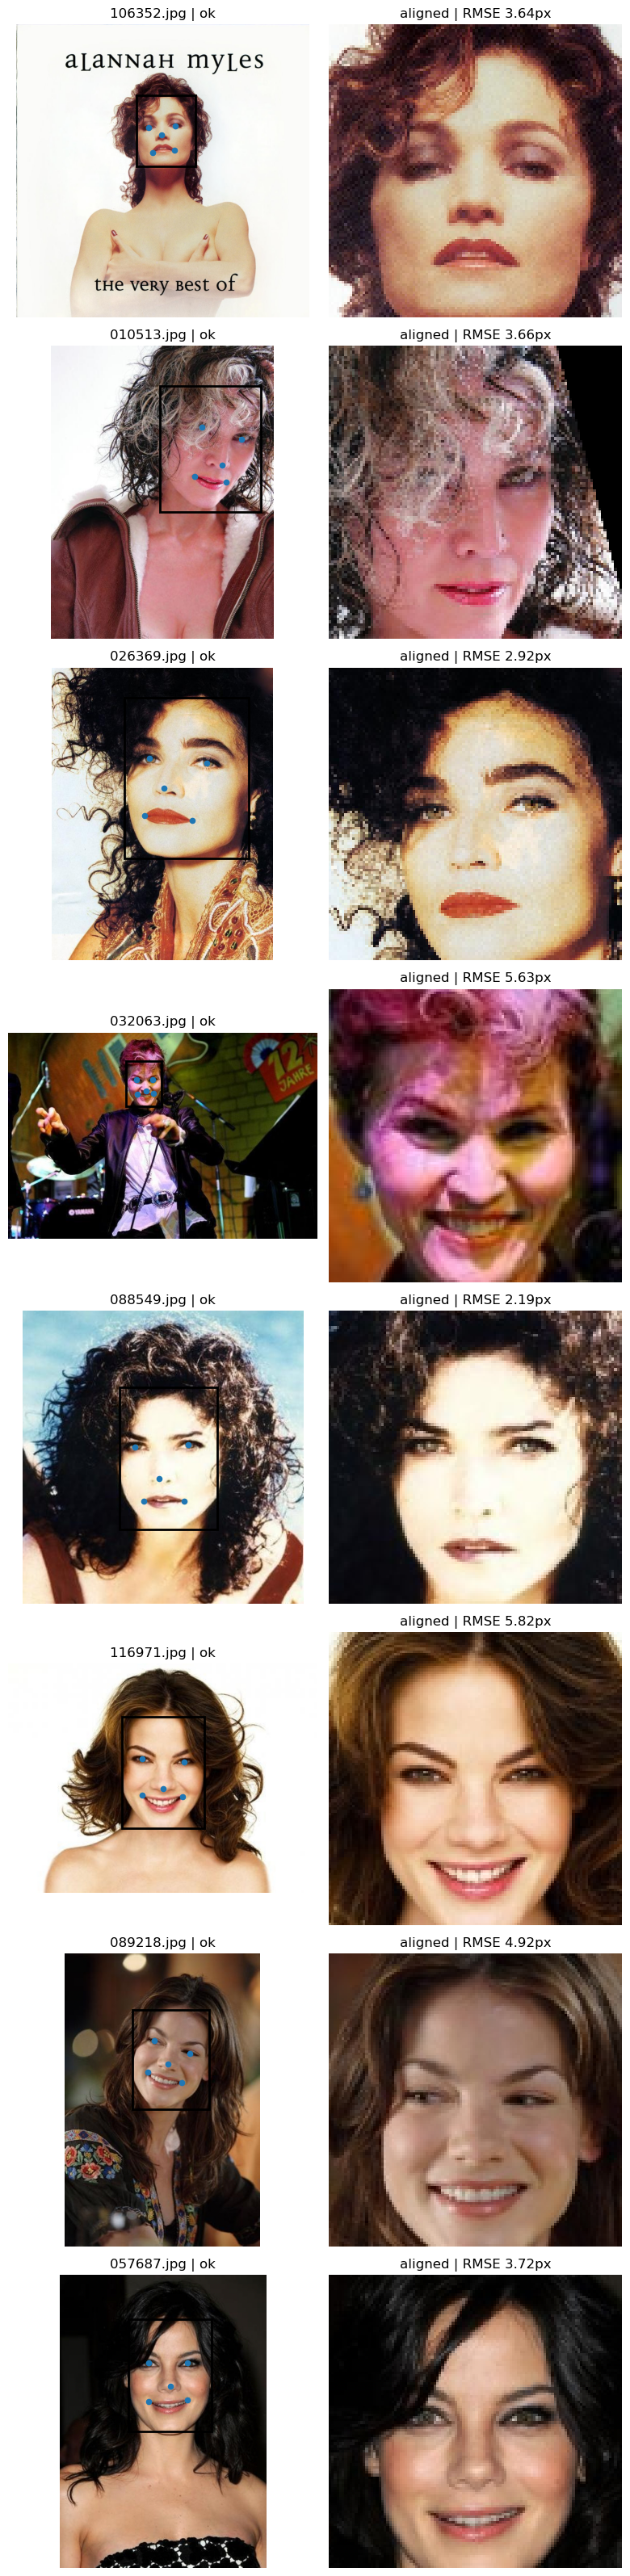

In [12]:
smoke_rows = (
    master[master["process_candidate"]]
    .sort_values(["identity_rank", "image_rank"])
    .head(8)
)

smoke_results = []

for row in smoke_rows.itertuples(index=False):
    image_rgb = np.asarray(Image.open(row.raw_path).convert("RGB"))
    result = run_face_frontend(image_rgb)
    smoke_results.append((row.filename, image_rgb, result))
    print(row.filename, "->", result["status"], result.get("failure_reason", ""))

fig, axes = plt.subplots(len(smoke_results), 2, figsize=(8, 4 * len(smoke_results)))
axes = np.atleast_2d(axes)

for i, (filename, image_rgb, result) in enumerate(smoke_results):
    axes[i, 0].imshow(image_rgb)
    if "bbox_xyxy" in result:
        x1, y1, x2, y2 = result["bbox_xyxy"]
        axes[i, 0].add_patch(
            plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
        )
    if "landmarks_original" in result:
        pts = result["landmarks_original"]
        axes[i, 0].scatter(pts[:, 0], pts[:, 1], s=20)
    axes[i, 0].set_title(f"{filename} | {result['status']}")
    axes[i, 0].axis("off")

    if result["status"] == "ok":
        axes[i, 1].imshow(result["aligned_rgb"])
        axes[i, 1].set_title(f"aligned | RMSE {result['template_rmse_px']:.2f}px")
    else:
        axes[i, 1].text(0.5, 0.5, result.get("failure_reason", "FAIL"),
                        ha="center", va="center")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 13. Process deterministic candidates

This cell writes **staging aligned images** and a separate `frontend_processing.csv`.

Important:

- candidates were selected before model preprocessing;
- failure is technical only;
- GT diagnostic scores are recorded but never used to accept/reject;
- reruns reuse prior processed rows unless `reprocess_existing=True`.

In [13]:
PROCESSING_PATH = CFG.output_root / "frontend_processing.csv"
STAGING_DIR = CFG.output_root / "staging_aligned"
STAGING_DIR.mkdir(parents=True, exist_ok=True)

def gt_diagnostics(filename, result):
    diagnostics = {
        "gt_bbox_iou": np.nan,
        "gt_landmark_nme": np.nan,
    }

    if result.get("status") != "ok":
        return diagnostics

    if gt_bbox is not None and filename in gt_bbox.index:
        r = gt_bbox.loc[filename]
        gt_box = np.array(
            [r.gt_x, r.gt_y, r.gt_x + r.gt_w, r.gt_y + r.gt_h],
            dtype=np.float32,
        )
        diagnostics["gt_bbox_iou"] = bbox_iou(
            result["bbox_xyxy"], gt_box
        )

    if gt_landmarks is not None and filename in gt_landmarks.index:
        r = gt_landmarks.loc[filename]
        gt_pts = r[LANDMARK_COLUMNS].to_numpy(dtype=np.float32).reshape(5, 2)
        diagnostics["gt_landmark_nme"] = landmark_nme(
            result["landmarks_original"], gt_pts
        )

    return diagnostics

def result_to_record(row, result, elapsed_s):
    rec = {
        "filename": row.filename,
        "identity_id": int(row.identity_id),
        "identity_pool": row.identity_pool,
        "candidate_role": row.candidate_role,
        "frontend_status": result["status"],
        "exclusion_reason": result.get("failure_reason", ""),
        "elapsed_s": float(elapsed_s),
        "aligned_staging_path": "",
    }

    if "bbox_xyxy" in result:
        b = result["bbox_xyxy"]
        rec.update({
            "bbox_x1": float(b[0]),
            "bbox_y1": float(b[1]),
            "bbox_x2": float(b[2]),
            "bbox_y2": float(b[3]),
            "det_score": float(result.get("det_score", np.nan)),
            "n_faces_detected": int(result.get("n_faces", 0)),
        })

    if "hg_meta" in result:
        rec.update(result["hg_meta"])

    if "landmarks_original" in result:
        pts = np.asarray(result["landmarks_original"])
        for name, (x, y) in zip(LANDMARK_NAMES, pts):
            rec[f"pred_{name}_x"] = float(x)
            rec[f"pred_{name}_y"] = float(y)

    if result["status"] == "ok":
        rec["template_rmse_px"] = float(result["template_rmse_px"])

    rec.update(gt_diagnostics(row.filename, result))
    return rec

existing = pd.DataFrame()
if PROCESSING_PATH.exists() and not CFG.reprocess_existing:
    existing = pd.read_csv(PROCESSING_PATH)
    processed_names = set(existing["filename"].astype(str))
    print("Reusing processed rows:", f"{len(processed_names):,}")
else:
    processed_names = set()

candidate_df = master[master["process_candidate"]].copy()
todo = candidate_df[~candidate_df["filename"].isin(processed_names)].copy()

print("Total candidate images:", f"{len(candidate_df):,}")
print("Already processed:", f"{len(processed_names):,}")
print("To process now:", f"{len(todo):,}")

records = []
t0 = time.time()

for i, row in enumerate(
    tqdm(todo.itertuples(index=False), total=len(todo), desc="Three-stage frontend"),
    start=1,
):
    start = time.perf_counter()

    try:
        image_rgb = np.asarray(Image.open(row.raw_path).convert("RGB"))
        result = run_face_frontend(image_rgb)

        if result["status"] == "ok" and CFG.save_staging_aligned:
            out_name = f"{int(row.identity_id):07d}__{row.filename}"
            out_path = STAGING_DIR / out_name
            Image.fromarray(result["aligned_rgb"]).save(
                out_path,
                quality=95,
                subsampling=0,
            )
        else:
            out_path = None

    except Exception as exc:
        result = {
            "status": "exception_fail",
            "failure_reason": f"{type(exc).__name__}: {exc}",
        }
        out_path = None

    rec = result_to_record(
        row,
        result,
        time.perf_counter() - start,
    )
    if out_path is not None:
        rec["aligned_staging_path"] = str(out_path)
    records.append(rec)

    if i % CFG.checkpoint_every == 0:
        batch_df = pd.DataFrame(records)
        combined = pd.concat([existing, batch_df], ignore_index=True)
        combined = combined.drop_duplicates("filename", keep="last")
        combined.to_csv(PROCESSING_PATH, index=False)
        existing = combined
        records = []
        gc.collect()

if records:
    combined = pd.concat([existing, pd.DataFrame(records)], ignore_index=True)
    combined = combined.drop_duplicates("filename", keep="last")
else:
    combined = existing.copy()

combined.to_csv(PROCESSING_PATH, index=False)

print("Processing complete.")
print("Elapsed, min:", round((time.time() - t0) / 60, 2))
display(combined["frontend_status"].value_counts(dropna=False).to_frame("count"))
print("Processing CSV:", PROCESSING_PATH)

Total candidate images: 42,254
Already processed: 0
To process now: 42,254


Three-stage frontend:   0%|          | 0/42254 [00:00<?, ?it/s]

Processing complete.
Elapsed, min: 35.61


,count
frontend_status,
ok,42192
bbox_fail,42
landmarks_fail,20


Processing CSV: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/frontend_processing.csv


## 14. Merge processing results back into the authoritative master manifest

In [14]:
processing = pd.read_csv(PROCESSING_PATH)

processing_cols = [
    c for c in processing.columns
    if c not in {"identity_id", "identity_pool", "candidate_role"}
]

master_base = master.drop(
    columns=[
        c for c in processing_cols
        if c in master.columns and c != "filename"
    ],
    errors="ignore",
)

master = master_base.merge(
    processing[processing_cols],
    on="filename",
    how="left",
)

master["frontend_status"] = master["frontend_status"].fillna("not_processed")
master["exclusion_reason"] = master["exclusion_reason"].fillna("")
master["aligned_staging_path"] = master["aligned_staging_path"].fillna("")

master.to_csv(MASTER_PATH, index=False)

print("Updated master:", MASTER_PATH)
display(master["frontend_status"].value_counts().to_frame("count"))

Updated master: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/master_manifest.csv


,count
frontend_status,
not_processed,160344
ok,42192
bbox_fail,42
landmarks_fail,20


## 15. Exact 21k finalization

Selection uses only:

- immutable preassigned candidate role;
- successful technical frontend status;
- deterministic pre-model identity/image ranking.

No GT metric and no recognition metric participates.

### Train

Target is 16,000 images. Identities must have at least 4 successful candidate images.  
The finalizer prefers 8 images/identity when available, otherwise takes 4. This keeps the final count divisible by four while avoiding a hard requirement that every identity have eight successful images.

### Validation

500 identities × 4 images = 2,000.

### Query

250 identities × 4 images = 1,000.

### Distractors

2,000 identities × 1 image = 2,000.

In [15]:
FINAL_ROOT = CFG.output_root / "celeba_21k_aligned"

def successful_role(role):
    return master[
        (master["candidate_role"] == role) &
        (master["frontend_status"] == "ok") &
        (master["aligned_staging_path"].astype(str) != "")
    ].copy()

def select_exact_per_identity(role_df, identity_count, images_per_identity):
    groups = {
        int(i): g.sort_values(["image_rank", "filename"])
        for i, g in role_df.groupby("identity_id")
        if len(g) >= images_per_identity
    }
    ordered_ids = sorted(
        groups,
        key=lambda i: stable_rank(i, CFG.seed),
    )
    if len(ordered_ids) < identity_count:
        raise RuntimeError(
            f"Insufficient successful identities: need {identity_count}, "
            f"have {len(ordered_ids)}."
        )
    chosen_ids = ordered_ids[:identity_count]
    selected = pd.concat(
        [groups[i].head(images_per_identity) for i in chosen_ids],
        ignore_index=True,
    )
    return selected

def select_train(role_df, target):
    groups = {
        int(i): g.sort_values(["image_rank", "filename"])
        for i, g in role_df.groupby("identity_id")
        if len(g) >= CFG.train_min_images_per_id
    }
    ordered_ids = sorted(groups, key=lambda i: stable_rank(i, CFG.seed))

    chunks = []
    total = 0

    for i in ordered_ids:
        g = groups[i]
        remaining = target - total
        if remaining <= 0:
            break

        # Preserve >=4 images/identity and exact divisibility.
        if len(g) >= CFG.train_preferred_images_per_id and remaining >= 8:
            take = 8
        elif remaining >= 4:
            take = 4
        else:
            break

        chunks.append(g.head(take))
        total += take

    if total != target:
        raise RuntimeError(
            f"Could not construct exact train target {target}; "
            f"constructed {total}. Increase train candidate reserves."
        )
    return pd.concat(chunks, ignore_index=True)

train_success = successful_role("train_candidate")
val_success = successful_role("validation_candidate")
query_success = successful_role("test_query_candidate")
distr_success = successful_role("test_distractor_candidate")

train_selected = select_train(train_success, CFG.train_target)

val_identity_count = CFG.val_target // CFG.val_images_per_id
query_identity_count = CFG.query_target // CFG.query_images_per_id

if val_identity_count * CFG.val_images_per_id != CFG.val_target:
    raise ValueError("val_target must be divisible by val_images_per_id.")
if query_identity_count * CFG.query_images_per_id != CFG.query_target:
    raise ValueError("query_target must be divisible by query_images_per_id.")

val_selected = select_exact_per_identity(
    val_success,
    val_identity_count,
    CFG.val_images_per_id,
)
query_selected = select_exact_per_identity(
    query_success,
    query_identity_count,
    CFG.query_images_per_id,
)
distr_selected = select_exact_per_identity(
    distr_success,
    CFG.distractor_target,
    1,
)

selections = {
    "train": train_selected,
    "validation": val_selected,
    "test_query": query_selected,
    "test_distractor": distr_selected,
}

# Identity leakage assertions BEFORE file export.
id_sets = {
    name: set(df["identity_id"].astype(int))
    for name, df in selections.items()
}
names = list(id_sets)
for a, b in combinations(names, 2):
    overlap = id_sets[a] & id_sets[b]
    if overlap:
        raise AssertionError(
            f"Identity leakage between {a} and {b}: {list(overlap)[:10]}"
        )

expected_counts = {
    "train": CFG.train_target,
    "validation": CFG.val_target,
    "test_query": CFG.query_target,
    "test_distractor": CFG.distractor_target,
}

for name, expected in expected_counts.items():
    actual = len(selections[name])
    if actual != expected:
        raise AssertionError(f"{name}: {actual} != {expected}")

print("All pre-export count and identity-disjointness assertions passed.")
for name, df in selections.items():
    print(
        f"{name:16s} images={len(df):5d} "
        f"identities={df['identity_id'].nunique():5d}"
    )

All pre-export count and identity-disjointness assertions passed.
train            images=16000 identities= 2087
validation       images= 2000 identities=  500
test_query       images= 1000 identities=  250
test_distractor  images= 2000 identities= 2000


## 16. Export selected aligned images and freeze final membership

In [16]:
subset_dir = {
    "train": FINAL_ROOT / "train",
    "validation": FINAL_ROOT / "validation",
    "test_query": FINAL_ROOT / "test/query",
    "test_distractor": FINAL_ROOT / "test/distractors",
}

for d in subset_dir.values():
    d.mkdir(parents=True, exist_ok=True)

selected_records = []

for subset, df in selections.items():
    out_dir = subset_dir[subset]

    for row in tqdm(
        df.itertuples(index=False),
        total=len(df),
        desc=f"Export {subset}",
    ):
        src = Path(row.aligned_staging_path)
        if not src.exists():
            raise FileNotFoundError(f"Missing staging aligned image: {src}")

        dst = out_dir / src.name
        if not dst.exists():
            shutil.copy2(src, dst)

        selected_records.append({
            "filename": row.filename,
            "identity_id": int(row.identity_id),
            "final_subset": subset,
            "aligned_path": str(dst),
        })

selected_df = pd.DataFrame(selected_records)

# Freeze final membership in the authoritative master.
master = master.drop(
    columns=["final_subset", "selected_final", "aligned_path"],
    errors="ignore",
)
master = master.merge(
    selected_df[["filename", "final_subset", "aligned_path"]],
    on="filename",
    how="left",
)
master["selected_final"] = master["final_subset"].notna()
master["final_subset"] = master["final_subset"].fillna("reserve")
master["aligned_path"] = master["aligned_path"].fillna("")

master.to_csv(MASTER_PATH, index=False)

FINAL_SELECTION_PATH = CFG.output_root / "final_21k_selection.csv"
selected_df.to_csv(FINAL_SELECTION_PATH, index=False)

print("Final selection:", FINAL_SELECTION_PATH)
print("Master manifest:", MASTER_PATH)

Export train:   0%|          | 0/16000 [00:00<?, ?it/s]

Export validation:   0%|          | 0/2000 [00:00<?, ?it/s]

Export test_query:   0%|          | 0/1000 [00:00<?, ?it/s]

Export test_distractor:   0%|          | 0/2000 [00:00<?, ?it/s]

Final selection: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/final_21k_selection.csv
Master manifest: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/master_manifest.csv


## 17. Final validation report + Identification Rate protocol counts

This cell validates the dataset contract before ArcFace/CE training.

`query_positive_pairs`, `query_negative_pairs`, and `query_distractor_pairs` describe the pair population expected by the original Identification Rate metric notebook. No embeddings are computed here.

In [17]:
final_df = master[master["selected_final"]].copy()

counts = final_df["final_subset"].value_counts().to_dict()
assert counts.get("train", 0) == CFG.train_target
assert counts.get("validation", 0) == CFG.val_target
assert counts.get("test_query", 0) == CFG.query_target
assert counts.get("test_distractor", 0) == CFG.distractor_target
assert len(final_df) == 21_000

final_id_sets = {
    subset: set(
        final_df.loc[final_df["final_subset"] == subset, "identity_id"].astype(int)
    )
    for subset in ["train", "validation", "test_query", "test_distractor"]
}

overlap_report = {}
for a, b in combinations(final_id_sets, 2):
    overlap = final_id_sets[a] & final_id_sets[b]
    overlap_report[f"{a}__{b}"] = len(overlap)
    assert not overlap, f"Identity leakage: {a} vs {b}"

query_df = final_df[final_df["final_subset"] == "test_query"]
distr_df = final_df[final_df["final_subset"] == "test_distractor"]

query_counts_by_id = query_df.groupby("identity_id").size()

query_positive_pairs = int(
    sum(n * (n - 1) // 2 for n in query_counts_by_id)
)
all_query_pairs = CFG.query_target * (CFG.query_target - 1) // 2
query_negative_pairs = int(all_query_pairs - query_positive_pairs)
query_distractor_pairs = int(CFG.query_target * CFG.distractor_target)

processing_summary = (
    master[master["process_candidate"]]["frontend_status"]
    .value_counts(dropna=False)
    .to_dict()
)

report = {
    "raw_manifest_images": int(len(master)),
    "raw_identities": int(master["identity_id"].nunique()),
    "candidate_images": int(master["process_candidate"].sum()),
    "processing_status": {str(k): int(v) for k, v in processing_summary.items()},
    "final_counts": {str(k): int(v) for k, v in counts.items()},
    "final_identity_counts": {
        subset: int(len(ids))
        for subset, ids in final_id_sets.items()
    },
    "identity_overlap_checks": overlap_report,
    "query_positive_pairs": query_positive_pairs,
    "query_negative_pairs": query_negative_pairs,
    "query_distractor_pairs": query_distractor_pairs,
}

REPORT_JSON = CFG.output_root / "dataset_validation_report.json"
with REPORT_JSON.open("w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(json.dumps(report, indent=2, ensure_ascii=False))
print("Validation report:", REPORT_JSON)

{
  "raw_manifest_images": 202598,
  "raw_identities": 10177,
  "candidate_images": 42254,
  "processing_status": {
    "ok": 42192,
    "bbox_fail": 42,
    "landmarks_fail": 20
  },
  "final_counts": {
    "train": 16000,
    "test_distractor": 2000,
    "validation": 2000,
    "test_query": 1000
  },
  "final_identity_counts": {
    "train": 2087,
    "validation": 500,
    "test_query": 250,
    "test_distractor": 2000
  },
  "identity_overlap_checks": {
    "train__validation": 0,
    "train__test_query": 0,
    "train__test_distractor": 0,
    "validation__test_query": 0,
    "validation__test_distractor": 0,
    "test_query__test_distractor": 0
  },
  "query_positive_pairs": 1500,
  "query_negative_pairs": 498000,
  "query_distractor_pairs": 2000000
}
Validation report: /Users/baal/Yandex.Disk.localized/WORK/PROg/DLS/DLS.2026.1.0весна/24-10_FinalProject/Pipeline_stage/0_align_block_for/out/celeba_wild_21k_frontend_v0_1/dataset_validation_report.json


## 18. Random final diagnostic collage

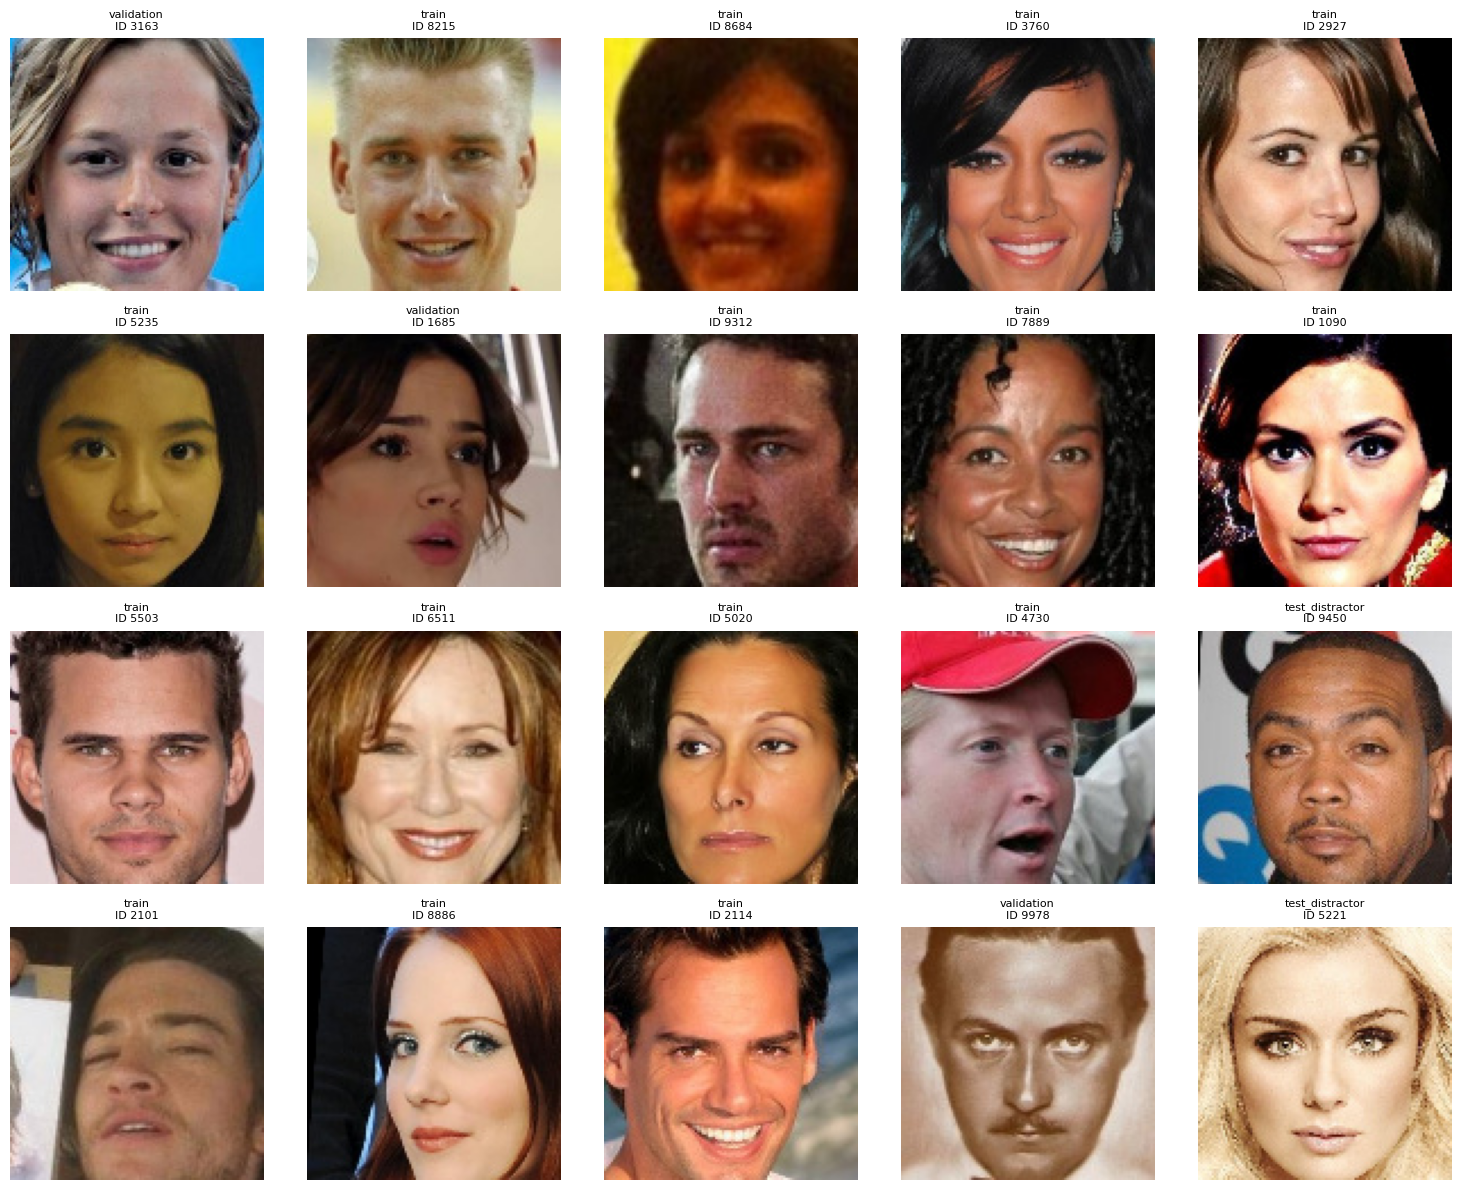

In [18]:
rng = np.random.default_rng(CFG.seed)

view = final_df.sample(
    n=min(CFG.diagnostic_sample_n, len(final_df)),
    random_state=CFG.seed,
).copy()

cols = 5
rows = math.ceil(len(view) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, row in zip(axes, view.itertuples(index=False)):
    img = np.asarray(Image.open(row.aligned_path).convert("RGB"))
    ax.imshow(img)
    ax.set_title(
        f"{row.final_subset}\nID {int(row.identity_id)}",
        fontsize=8,
    )
    ax.axis("off")

for ax in axes[len(view):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 19. Controlled GT diagnostic summary

These metrics are **diagnostic only** and were not used to construct the final split.

- `gt_bbox_iou`: YuNet bbox vs CelebA native GT bbox.
- `gt_landmark_nme`: predicted Double Hourglass landmarks vs native CelebA GT landmarks, normalized by GT interocular distance.

They help attribute front-end errors before ArcFace is connected.

In [19]:
diag = master[
    (master["frontend_status"] == "ok") &
    master["process_candidate"]
].copy()

for metric in ["gt_bbox_iou", "gt_landmark_nme", "template_rmse_px"]:
    if metric in diag.columns:
        s = pd.to_numeric(diag[metric], errors="coerce").dropna()
        if len(s):
            print(
                f"{metric}: n={len(s):,} "
                f"mean={s.mean():.6f} "
                f"median={s.median():.6f} "
                f"p95={s.quantile(0.95):.6f}"
            )

gt_bbox_iou: n=42,192 mean=0.631553 median=0.628205 p95=0.804559
gt_landmark_nme: n=42,192 mean=0.049407 median=0.026137 p95=0.065494
template_rmse_px: n=42,192 mean=3.942599 median=3.758206 p95=6.765300


## 20. Handoff boundary

After this notebook passes all assertions, downstream work may use:

```text
celeba_21k_aligned/
    train/
    validation/
    test/query/
    test/distractors/
```

together with:

```text
master_manifest.csv
final_21k_selection.csv
dataset_validation_report.json
```

### Next stage

Reconnect the existing ArcFace / Cross-Entropy training path **without redefining the split**.

For the final Identification Rate / `TPR@FPR` evaluation:

```text
positive:
    query-query, same identity

negative:
    query-query, different identity
    query-distractor
```

The final test identities must remain unseen during training, validation, checkpoint selection and threshold/hyperparameter tuning.